# Full architecture: modular error corrector

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Не удалось найти корень репозитория")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.full_corrector import (
    CorrectorConfig,
    MultiCorrector,
    evaluate_corrector,
    load_feature_csv,
    plot_cluster_score_distributions,
    plot_cluster_sizes,
    plot_confusion_matrix,
    plot_dispatcher_projection,
    plot_roc_curve,
    plot_score_distribution,
    split_correct_wrong,
)

In [2]:
DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "output" / "full_architecture"
MODEL_DIR = REPO_ROOT / "models" / "full_architecture"

TP_PATH = DATA_DIR / "TP.csv"
FP_PATH = DATA_DIR / "FP.csv"

RANDOM_STATE = 42
TRAIN_FRACTION = 0.5
N_COMPONENTS = 200
N_CLUSTERS = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert TP_PATH.exists(), f"Нет файла {TP_PATH}"
assert FP_PATH.exists(), f"Нет файла {FP_PATH}"

REPO_ROOT

PosixPath('/home/minin/workspace/ErrorCorrector')

## Подготовка данных

In [3]:
correct = load_feature_csv(TP_PATH)
wrong = load_feature_csv(FP_PATH)

split = split_correct_wrong(
    correct,
    wrong,
    train_fraction=TRAIN_FRACTION,
    random_state=RANDOM_STATE,
)
split.save(OUTPUT_DIR / "split.npz")

pd.DataFrame(
    {
        "subset": ["CR train", "CR test", "WR train", "WR test"],
        "n_objects": [
            len(split.correct_train),
            len(split.correct_test),
            len(split.wrong_train),
            len(split.wrong_test),
        ],
        "n_features": [
            split.correct_train.shape[1],
            split.correct_test.shape[1],
            split.wrong_train.shape[1],
            split.wrong_test.shape[1],
        ],
    }
)

,subset,n_objects,n_features
0,CR train,934,1810
1,CR test,934,1810
2,WR train,18,1810
3,WR test,18,1810


## Обучение multi-corrector


In [4]:
n_clusters = min(N_CLUSTERS, len(split.wrong_train))
if n_clusters < N_CLUSTERS:
    print(f"N_CLUSTERS уменьшен с {N_CLUSTERS} до {n_clusters}: WR train слишком маленький.")

config = CorrectorConfig(
    n_components=N_COMPONENTS,
    n_clusters=n_clusters,
    centre_on="correct",
    whiten=False,
    regularization=1e-6,
    random_state=RANDOM_STATE,
)

model = MultiCorrector(config).fit(split.correct_train, split.wrong_train)
model.save(MODEL_DIR / "multi_corrector.pkl")

pd.DataFrame(
    {
        "cluster": range(model.config.n_clusters),
        "wrong_train_objects": model.cluster_sizes_,
    }
)

,cluster,wrong_train_objects
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
5,5,2
6,6,3
7,7,1
8,8,1
9,9,1


## Метрики


In [5]:
result = evaluate_corrector(model, split, clustered=True)
result.save(OUTPUT_DIR / "metrics_multi_corrector.json")

rows = []
for subset_name, metrics in [("train", result.train), ("test", result.test)]:
    row = asdict(metrics)
    row.pop("confusion_matrix")
    row["subset"] = subset_name
    rows.append(row)

metrics_frame = pd.DataFrame(rows)
metrics_frame[
    [
        "subset",
        "balanced_accuracy",
        "roc_auc",
        "sensitivity",
        "specificity",
        "threshold",
    ]
]

,subset,balanced_accuracy,roc_auc,sensitivity,specificity,threshold
0,train,0.996788,0.998989,1.000000,0.993576,53.590258
1,test,0.713657,0.831608,0.444444,0.982869,53.590258


## Графики


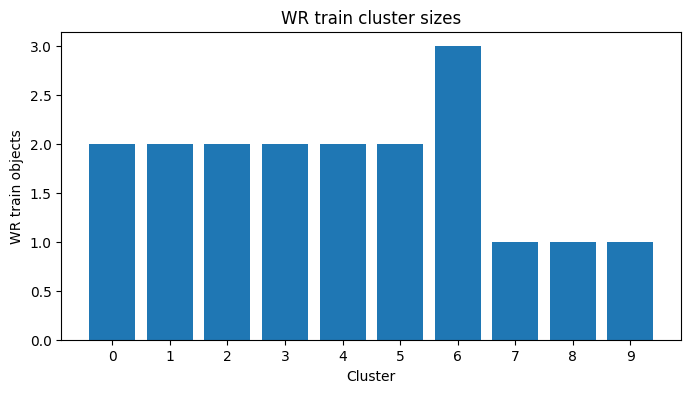

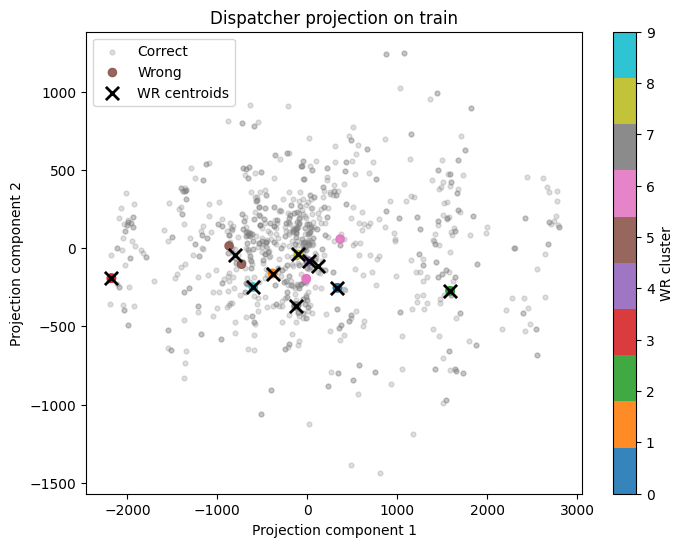

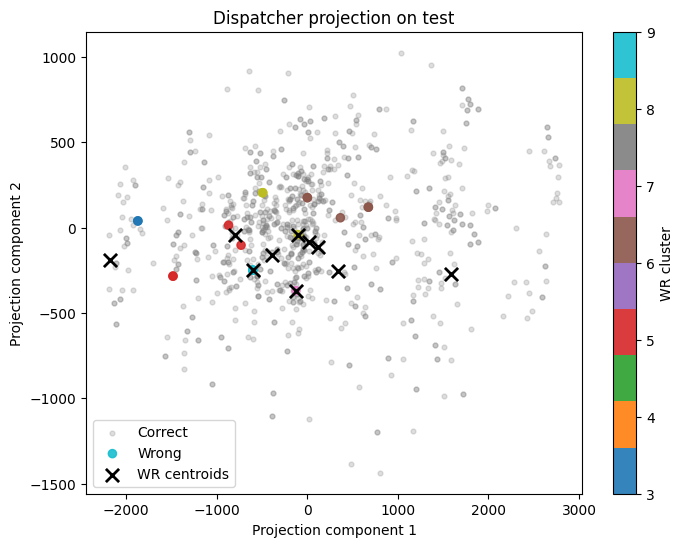

In [6]:
plot_cluster_sizes(
    model,
    title="WR train cluster sizes",
    path=OUTPUT_DIR / "cluster_sizes.png",
)
plt.show()

plot_dispatcher_projection(
    model,
    split.correct_train,
    split.wrong_train,
    title="Dispatcher projection on train",
    path=OUTPUT_DIR / "dispatcher_projection_train.png",
)
plt.show()

plot_dispatcher_projection(
    model,
    split.correct_test,
    split.wrong_test,
    title="Dispatcher projection on test",
    path=OUTPUT_DIR / "dispatcher_projection_test.png",
)
plt.show()

## Распределения score

Чем выше error score, тем сильнее объект похож на ошибочный для соответствующего локального сепараторав

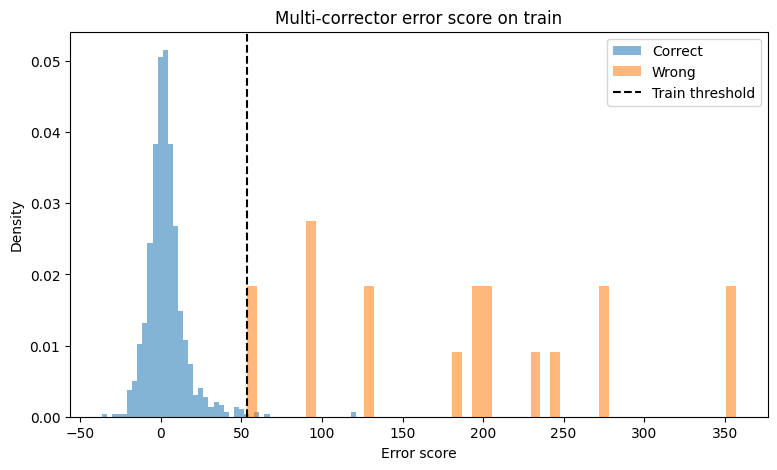

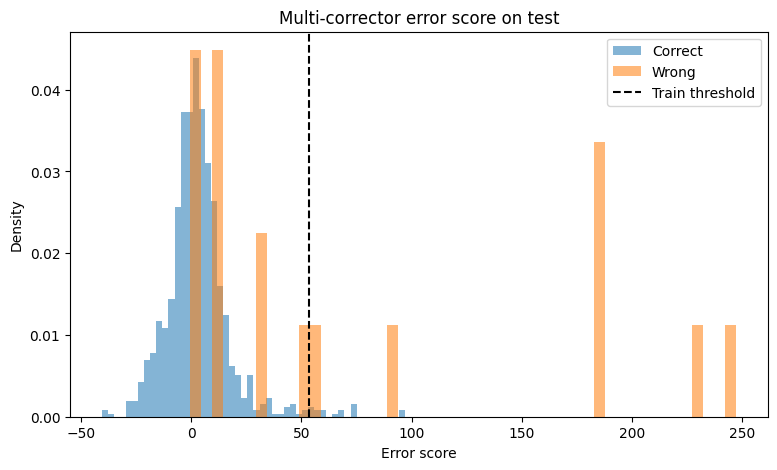

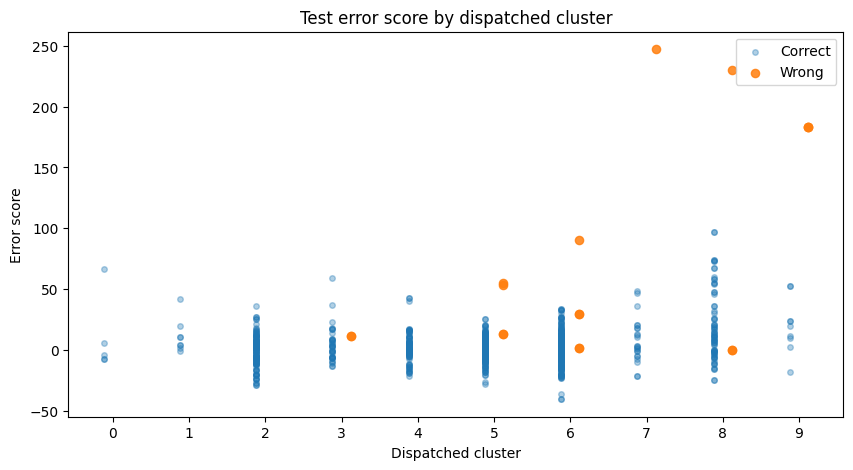

In [7]:
plot_score_distribution(
    model,
    split.correct_train,
    split.wrong_train,
    threshold=result.train.threshold,
    clustered=True,
    title="Multi-corrector error score on train",
    path=OUTPUT_DIR / "score_distribution_train.png",
)
plt.show()

plot_score_distribution(
    model,
    split.correct_test,
    split.wrong_test,
    threshold=result.train.threshold,
    clustered=True,
    title="Multi-corrector error score on test",
    path=OUTPUT_DIR / "score_distribution_test.png",
)
plt.show()

plot_cluster_score_distributions(
    model,
    split.correct_test,
    split.wrong_test,
    title="Test error score by dispatched cluster",
    path=OUTPUT_DIR / "cluster_score_distribution_test.png",
)
plt.show()

## ROC и CM

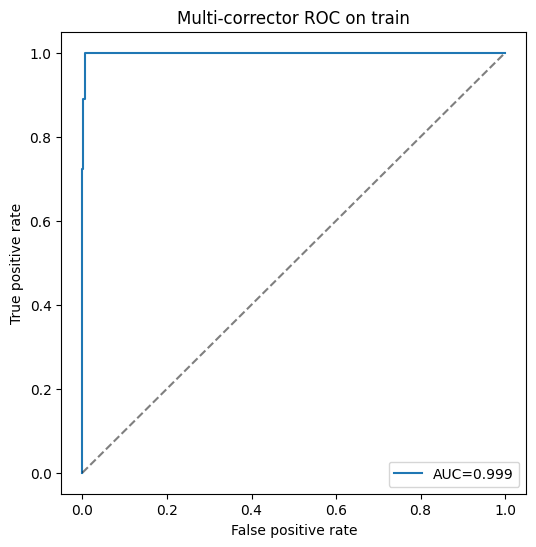

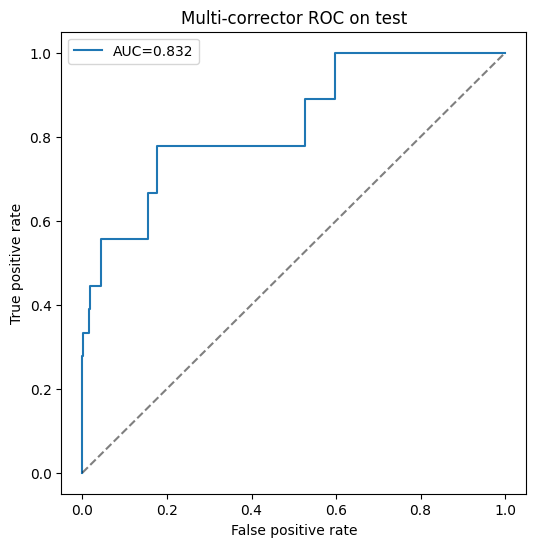

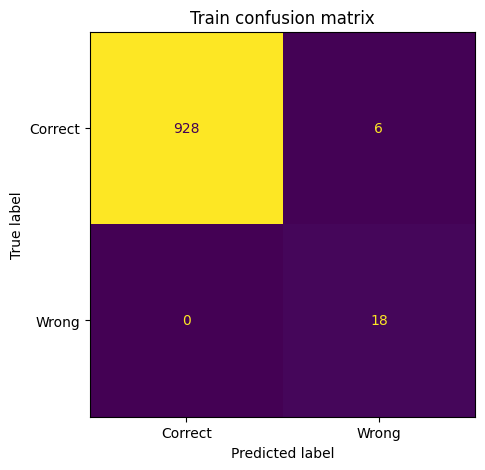

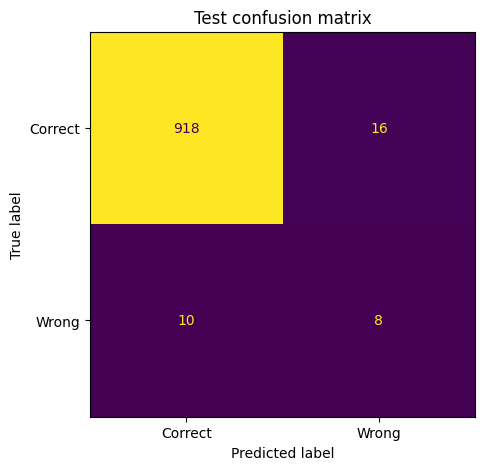

In [8]:
plot_roc_curve(
    model,
    split.correct_train,
    split.wrong_train,
    clustered=True,
    title="Multi-corrector ROC on train",
    path=OUTPUT_DIR / "roc_train.png",
)
plt.show()

plot_roc_curve(
    model,
    split.correct_test,
    split.wrong_test,
    clustered=True,
    title="Multi-corrector ROC on test",
    path=OUTPUT_DIR / "roc_test.png",
)
plt.show()

plot_confusion_matrix(
    result.train,
    title="Train confusion matrix",
    path=OUTPUT_DIR / "confusion_matrix_train.png",
)
plt.show()

plot_confusion_matrix(
    result.test,
    title="Test confusion matrix",
    path=OUTPUT_DIR / "confusion_matrix_test.png",
)
plt.show()